In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import nltk
import pandas as pd
import seaborn as sns
from langdetect import DetectorFactory, LangDetectException, detect
from nltk.corpus import opinion_lexicon
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from transformers import pipeline
from wordcloud import WordCloud

## 1. Import data.

Make sure all the files are in the working directory.

In [26]:
csv_paths = list(Path("../Dataset/data_old_approach/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
bank_of_america__combined_us.csv
chase__combined_us.csv
citi__combined_us.csv
marcus_by_goldman_sachs__combined_us.csv
wells_fargo__combined_us.csv


In [27]:
# import files
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

## 2. Data Overview

In [28]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5450 entries, 0 to 5449
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform       5450 non-null   object
 1   storefront     5450 non-null   object
 2   app_id         2450 non-null   object
 3   review_id      5450 non-null   object
 4   date           5450 non-null   object
 5   user           5450 non-null   object
 6   rating         5450 non-null   object
 7   title          2450 non-null   object
 8   review         5450 non-null   object
 9   version        2450 non-null   object
 10  package        3000 non-null   object
 11  thumbsUpCount  3000 non-null   object
 12  appVersion     2717 non-null   object
 13  source_file    5450 non-null   object
dtypes: object(14)
memory usage: 596.2+ KB


In [29]:
raw.describe(include = "all")

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
count,5450,5450,2450,5450,5450,5450,5450,2450,5450,2450,3000,3000,2717,5450
unique,2,1,5,5450,5449,5404,5,2058,4929,55,5,29,93,5
top,google_play,us,284847138.0,13566342702,2025-12-17 16:42:21,A Google user,5,Easy to use,good,25.10.04,com.infonow.bofa,0.0,9.90.0,bank_of_america__combined_us.csv
freq,3000,5450,490,1,2,16,3032,17,47,268,600,2623,508,1090


In [ ]:
raw.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,us,284847138.0,13566342702,2025-12-28T13:28:49-07:00,EBP1940,1,Horrible.,I can’t load the banking app bc it requires a ...,25.04.06,NaN,NaN,NaN,bank_of_america__combined_us.csv
1,app_store,us,284847138.0,13566341104,2025-12-28T13:28:13-07:00,papemahi,5,Enjoy,Good\r\nGood,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
2,app_store,us,284847138.0,13566049201,2025-12-28T11:48:52-07:00,Jiankun Li,5,Bank Of America Application Benefit,Bank Of America has an application which allow...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
3,app_store,us,284847138.0,13565792340,2025-12-28T10:27:09-07:00,Tom nrady,5,App,The app is easy to use for a 63-year-old woman...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
4,app_store,us,284847138.0,13564879934,2025-12-28T05:55:07-07:00,Banco América,5,Mi banco,Muy bien,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv


In [31]:
platform_counts = (
    raw
    .groupby("platform")
    .size()
    .reset_index(name="n_reviews")
)

platform_counts

,platform,n_reviews
0,app_store,2450
1,google_play,3000


In [32]:
missing_raw = (
    raw
    .isna()
    .sum()
    .reset_index()
)

missing_raw.columns = ["variable", "n_missing"]

missing_raw = (
    missing_raw
    .sort_values("n_missing", ascending=False)
    .reset_index(drop=True)
)

missing_raw

,variable,n_missing
0,app_id,3000
1,title,3000
2,version,3000
3,appVersion,2733
4,package,2450
5,thumbsUpCount,2450
6,platform,0
7,storefront,0
8,review_id,0
9,date,0


In [33]:
missing_by_platform = (
    raw
    .groupby("platform")
    .agg(lambda col: col.isna().sum())
    .reset_index()
)

missing_by_platform

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,0,0,0,0,0,0,0,0,0,2450,2450,2450,0
1,google_play,0,3000,0,0,0,0,3000,0,3000,0,0,283,0


In [34]:
raw["raw_text"] = (
    raw["title"].fillna("") + " " + raw["review"].fillna("")
)

raw["raw_length_words"] = (
    raw["raw_text"]
    .str.count(r"\S+")
)

In [35]:
raw["raw_length_words"].describe()

count    5450.000000
mean       22.933394
std        30.588918
min         1.000000
25%         4.000000
50%        12.000000
75%        30.000000
max       411.000000
Name: raw_length_words, dtype: float64

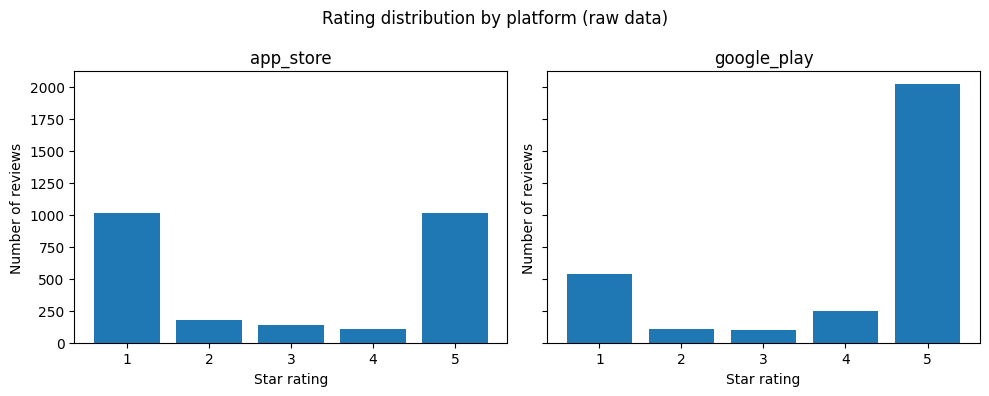

In [36]:
# Count the ratings by platform
rating_counts = (
    raw
    .groupby(["platform", "rating"])
    .size()
    .reset_index(name="n_reviews")
)

# Create one bar chart per platform
platforms = rating_counts["platform"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(10, 4),
    sharey=True
)

# If there is only one platform, make axes iterable
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    data = rating_counts[rating_counts["platform"] == platform]

    ax.bar(data["rating"], data["n_reviews"])
    ax.set_title(platform)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Number of reviews")

fig.suptitle("Rating distribution by platform (raw data)")
plt.tight_layout()
plt.show()

## 3. Unigram Sentiment Analysis

### BING

In [45]:
# download Bing-style opinion lexicon
nltk.download("opinion_lexicon")

# Create Bing-style sentiment dataframe
positive_words = opinion_lexicon.positive()
negative_words = opinion_lexicon.negative()

bing = pd.DataFrame({
    "word": list(positive_words) + list(negative_words),
    "sentiment": ["positive"] * len(positive_words) + ["negative"] * len(negative_words)
})

# make sure tokenized reviews keep all original columns
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .str.findall(r"\b[a-z]+\b")
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

# remove stopwords
reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(custom_stop_words)
].copy()

# inner join with Bing-style sentiment lexicon
bing_words = reviews_after_sw.merge(
    bing,
    on="word",
    how="inner"
)

bing_words.head()

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     C:\Users\zuzia\AppData\Roaming\nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,word,sentiment
0,iOS,us,284847138.0,13566342702,2025-12-28 13:28:49-07:00,EBP1940,1,Horrible.,I can’t load the banking app bc it requires a ...,25.04.06,NaN,NaN,NaN,bank_of_america__combined_us.csv,Horrible. I can’t load the banking app bc it r...,36,Bank Of America,en,horrible,negative
1,iOS,us,284847138.0,13566342702,2025-12-28 13:28:49-07:00,EBP1940,1,Horrible.,I can’t load the banking app bc it requires a ...,25.04.06,NaN,NaN,NaN,bank_of_america__combined_us.csv,Horrible. I can’t load the banking app bc it r...,36,Bank Of America,en,horrible,negative
2,iOS,us,284847138.0,13544448557,2025-12-22 18:00:45-07:00,YoSheMe,1,What is Going On?,Bank of America’s app has not been working as ...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,What is Going On? Bank of America’s app has no...,68,Bank Of America,en,horrible,negative
3,iOS,us,284847138.0,13536162384,2025-12-20 12:35:05-07:00,InvestorTee,1,Horrible,This is a horrible app. It does not deserve ev...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,Horrible This is a horrible app. It does not d...,13,Bank Of America,en,horrible,negative
4,iOS,us,284847138.0,13536162384,2025-12-20 12:35:05-07:00,InvestorTee,1,Horrible,This is a horrible app. It does not deserve ev...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,Horrible This is a horrible app. It does not d...,13,Bank Of America,en,horrible,negative


In [46]:
bing_words_sentiment_counts = (
    bing_words["sentiment"]
    .value_counts()
    .reset_index()
)

bing_words_sentiment_counts.columns = ["sentiment", "n"]

bing_words_sentiment_counts

,sentiment,n
0,positive,7538
1,negative,3882


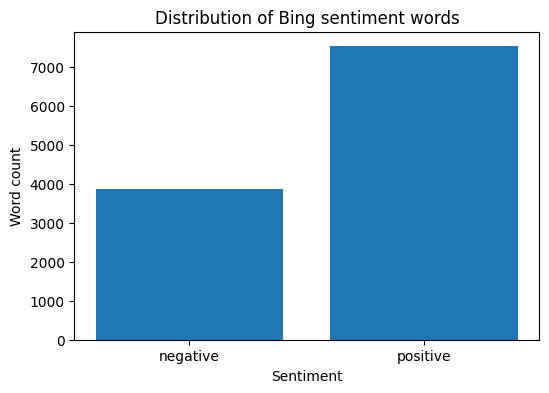

In [ ]:
# count sentiment words
sentiment_counts = (
    bing_words
    .groupby("sentiment")
    .size()
    .reset_index(name="n")
)

# plot
plt.figure(figsize=(6, 4))

plt.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["n"]
)

plt.title("Distribution of Bing sentiment words")
plt.xlabel("Sentiment")
plt.ylabel("Word count")

plt.show()

In [49]:
top_bing_words = (
    bing_words
    .groupby(["sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby("sentiment", group_keys=False)
    .head(10)
)

top_bing_words

,sentiment,word,n
728,positive,easy,973
801,positive,great,639
854,positive,love,409
849,positive,like,361
795,positive,good,361
665,positive,best,249
1053,positive,work,208
1055,positive,works,182
1042,positive,well,142
964,positive,savings,141


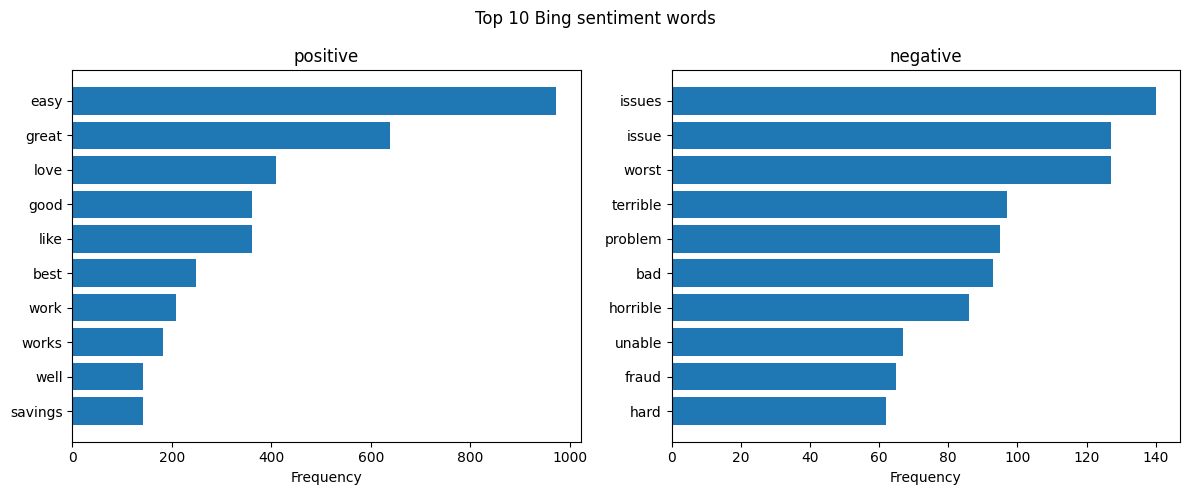

In [50]:
sentiments = top_bing_words["sentiment"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sentiments),
    figsize=(12, 5),
    sharex=False
)

if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sentiments):
    data = (
        top_bing_words[top_bing_words["sentiment"] == sentiment]
        .sort_values("n")
    )

    ax.barh(data["word"], data["n"])
    ax.set_title(sentiment)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

fig.suptitle("Top 10 Bing sentiment words")
plt.tight_layout()
plt.show()

In [51]:
bing_by_bank = (
    bing_words
    .groupby(["bank", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["bank", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_bank

,bank,sentiment,word,n
0,Citi,positive,easy,286
1,Marcus By Goldman Sachs,positive,easy,230
2,Bank Of America,positive,easy,181
3,Marcus By Goldman Sachs,positive,great,166
4,Wells Fargo,positive,easy,146
...,...,...,...,...
95,Wells Fargo,negative,unable,11
96,Wells Fargo,negative,terrible,11
97,Wells Fargo,negative,slow,10
98,Wells Fargo,negative,fraud,8


# 4. Transformer Based Sentiment Analysis